# Generative Bayesian Optimization: Learning Changeover Times

We want to simulate the factory starting with **Zero prior knowledge** (Day 1 of 2025). We cannot use historical averages from 2025, because that would be data leakage.

Instead, if we have never seen a transition before, we assume a **Flat Uninformative Prior**. Since physical changeovers are capped at 12 hours mechanically, we use a Uniform bounds assumption $U(0, 12)$, which drops the Day 1 baseline expected value to exactly **6.0 hours**.

However, to mathematically handle real incoming data (waiting times follow an Exponential distribution), we map this uninformative state to a Gamma conjugate prior by taking the theoretical limit $\alpha \approx 1.001, \beta \approx 0$.

Let's visualize how the system "learns" a transition that actually takes ~5h.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Presentation Styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### 1. Setting the Flat Prior and Simulating Reality

We set our Bayesian $\alpha$ virtually at 1, which represents complete ignorance. If 0 samples are passed to the optimizer, it will return the Uniform assumption of 6.0 hours.

In [10]:
# 1. Uninformative / Flat Prior
changeover_prior_alpha = 1.001
prior_beta = 0.001

print(f"Prior Alpha: {changeover_prior_alpha}")
print(f"Prior Beta: {prior_beta}")

# 2. The Unknown Reality
true_transition_mean = 5.0
np.random.seed(42)

# 20 random historical production runs in 2025 where this transition happened
real_samples = np.random.exponential(scale=true_transition_mean, size=20)
print(f"\nFirst 5 2025 observations (hours): {real_samples[:5].round(2)}")

Prior Alpha: 1.001
Prior Beta: 0.001

First 5 2025 observations (hours): [ 2.35 15.05  6.58  4.56  0.85]


In [11]:
def plot_posterior(samples_observed, ax, color):
    """Calculates posterior Gamma and plots the expected mean duration"""
    n = len(samples_observed)
    
    # 0 Samples Fallback (Uniform Assumption U(0,12) -> Mean = 6.0h)
    if n == 0:
        ax.hlines(y=1/12, xmin=0, xmax=12, color=color, linewidth=3, label="Uniform PDF U(0,12)")
        ax.axvline(6.0, linestyle="--", color=color, linewidth=2, label="Uniform Mean: 6.0h")
        ax.set_title("Knowledge at 0 observations (Flat/Uniform)", fontsize=14, pad=10)
        ax.set_xlim(0, 12)
        ax.set_ylim(0, 0.15)
        ax.legend()
        return
        
    sum_x = np.sum(samples_observed)
    
    # EXACT codebase conjugate update
    alpha = changeover_prior_alpha + n
    beta = prior_beta + sum_x
    
    rates = np.random.gamma(shape=alpha, scale=1.0 / beta, size=20000)
    expected_durations = 1.0 / rates
    expected_durations = expected_durations[expected_durations < 12] 
    
    sns.kdeplot(expected_durations, ax=ax, fill=True, color=color, alpha=0.4, linewidth=2)
    
    bayes_mean = beta / max(alpha - 1.0, 0.001)
    
    ax.axvline(bayes_mean, linestyle="--", color=color, linewidth=2, 
               label=f"Bayes Mean: {bayes_mean:.2f}h")
    ax.axvline(true_transition_mean, linestyle=":", color="black", alpha=0.6,
               label=f"True Reality: {true_transition_mean}h")
    
    ax.set_title(f"Knowledge after {n} observations", fontsize=14, pad=10)
    ax.set_xlim(0, 10)
    ax.legend()

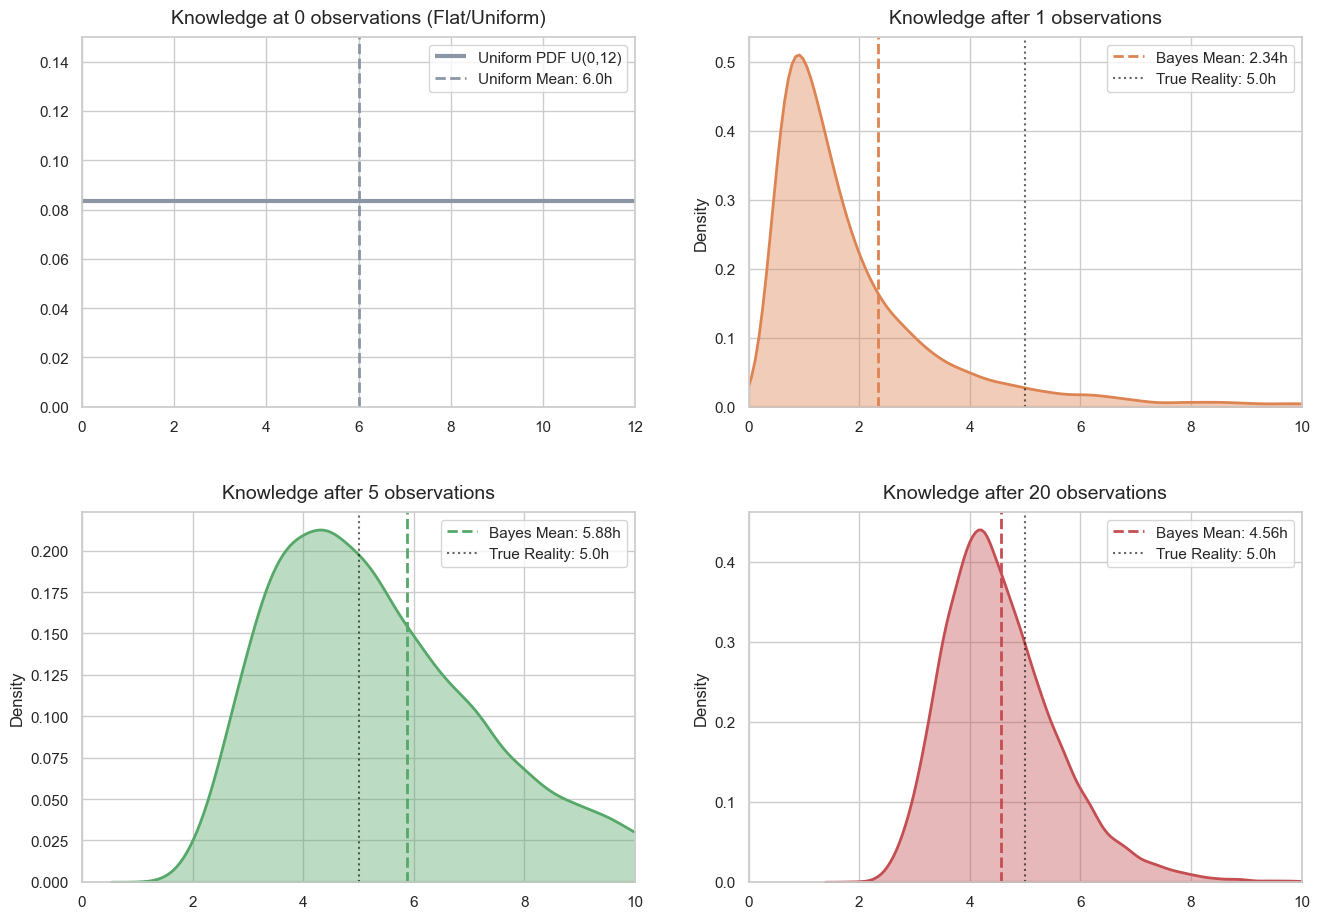

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# N = 0 (Uniform Flat Prior)
plot_posterior(real_samples[:0], axes[0, 0], color="#8B95A5")

# N = 1 (Immediate learning - heavily adopts the data since prior is weak)
plot_posterior(real_samples[:1], axes[0, 1], color="#dd8452")  

# N = 5 
plot_posterior(real_samples[:5], axes[1, 0], color="#55a868")  

# N = 20 (Converged on reality)
plot_posterior(real_samples[:20], axes[1, 1], color="#c44e52") 

plt.tight_layout(pad=3.0)
plt.show()